<a href="https://colab.research.google.com/github/greeshmakrishnan00/NLP/blob/main/EMAIL_SPAM_DETECTION_NLP_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/spam_mail_plus_10000_rows.csv")
df

,Category,Masseges
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
15567,ham,"Cool, what time you think you can get here? !"
15568,spam,You have been specially selected to receive a ...
15569,ham,Still at west coast... Haiz... ÌÏ'll take fore...
15570,ham,Dare i ask... Any luck with sorting out the car?


In [ ]:
texts= df.Masseges

In [ ]:
labels= df.Category

In [ ]:
df.isnull().sum()

,0
Category,0
Masseges,0


In [ ]:
df.duplicated().sum()

np.int64(5481)

In [ ]:
df.drop_duplicates(inplace=True)

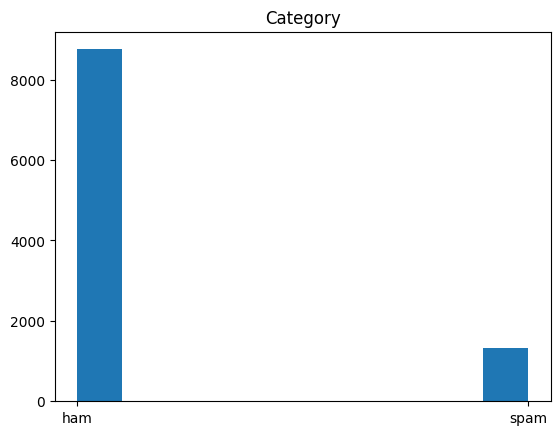

In [ ]:
plt.hist(df["Category"])
plt.title("Category")
plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=5000)

x = cv.fit_transform(df['Masseges']).toarray()

y = df['Category']

In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Apply SMOTE
smote = SMOTE(random_state=42)

x_resampled, y_resampled = smote.fit_resample(x, y)

# Display class distribution after balancing
print("Class Distribution After SMOTE:")
print(pd.Series(y_resampled).value_counts())

# Optional: Create balanced DataFrame
if hasattr(cv, "get_feature_names_out"):
    feature_names = cv.get_feature_names_out()

    df_resampled = pd.concat(
        [
            pd.DataFrame(x_resampled, columns=feature_names),
            pd.DataFrame(y_resampled, columns=['Category'])
        ],
        axis=1
    )

    print("\nBalanced Dataset Shape:")
    print(df_resampled.shape)

    print("\nFirst 5 Rows:")
    print(df_resampled.head())

Class Distribution After SMOTE:
Category
ham     8754
spam    8754
Name: count, dtype: int64

Balanced Dataset Shape:
(17508, 5001)

First 5 Rows:
   00  000  008704050406  02  0207  02072069400  02073162414  021  03  04  \
0   0    0             0   0     0            0            0    0   0   0   
1   0    0             0   0     0            0            0    0   0   0   
2   0    0             0   0     0            0            0    0   0   0   
3   0    0             0   0     0            0            0    0   0   0   
4   0    0             0   0     0            0            0    0   0   0   

   ...  û_  û_thanks  ûªm  ûªt  ûªve  ûï  ûïharry  ûò  ûówell  Category  
0  ...   0         0    0    0     0   0        0   0       0       ham  
1  ...   0         0    0    0     0   0        0   0       0       ham  
2  ...   0         0    0    0     0   0        0   0       0      spam  
3  ...   0         0    0    0     0   0        0   0       0       ham  
4  ...   0         0

In [ ]:
df= df_resampled

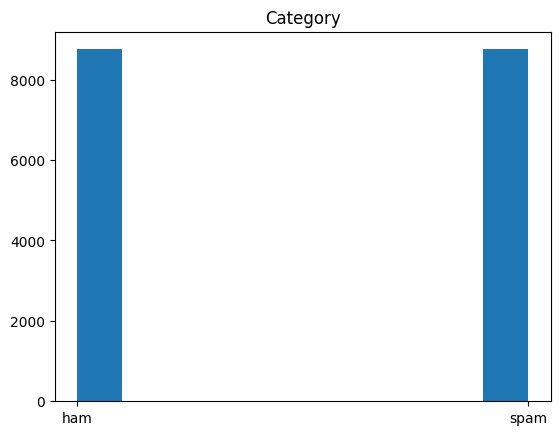

In [ ]:
plt.hist(df["Category"])
plt.title("Category")
plt.show()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

#  Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.25, random_state=42
)

#  Create the pipeline
pipe = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', MultinomialNB())
])

#  Train the model
pipe.fit(X_train, y_train)

#  Make predictions
preds = pipe.predict(X_test)

#  Evaluate the model
print("Test predictions:", preds)
print("Actual labels:   ", y_test)
print("Accuracy:", accuracy_score(y_test, preds))

#  Try a new example
new_text = ["Congratulations, you won a free ticket!"]
new_pred = pipe.predict(new_text)
print("\nNew text:", new_text[0])
print("Predicted label:", new_pred[0])

Test predictions: ['ham' 'ham' 'ham' ... 'ham' 'ham' 'ham']
Actual labels:    12438    ham
7272     ham
3260     ham
3689     ham
11953    ham
        ... 
9395     ham
8834     ham
3980     ham
180      ham
9758     ham
Name: Category, Length: 3893, dtype: object
Accuracy: 0.9935782173131261

New text: Congratulations, you won a free ticket!
Predicted label: spam
